In [12]:
# Imports
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import umap
import hdbscan
import random
import torch


In [13]:
# Load Questions
cq_path = "competency_questions_output/competency_questions_200_documents.txt"
with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', content, re.DOTALL)
questions = list(dict.fromkeys(questions))


Generate Clusters

In [14]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
# Sentence Embedding (SBERT)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
#model = SentenceTransformer("mixedbread-ai/deepset-mxbai-embed-de-large-v1")
embeddings = model.encode(questions)

# Dimensionality Reduction (UMAP, optional but good for HDBSCAN & visualization)
umap_reducer = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
X_umap = umap_reducer.fit_transform(embeddings)

# HDBSCAN clustering (as in the Ntropy article)
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, metric='euclidean', prediction_data=True)
labels = clusterer.fit_predict(X_umap)

# Print Number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"📌 Number of clusters found by HDBSCAN: {n_clusters}")


c:\Users\fabia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fabia\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


📌 Number of clusters found by HDBSCAN: 33


c:\Users\fabia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\fabia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


📈 Silhouette Score (without outliers): 0.5109


C:\Users\fabia\AppData\Local\Temp\ipykernel_9840\1765698300.py:12: UserWarning: 
The palette list has fewer values (33) than needed (34) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels, palette=palette, legend='full')


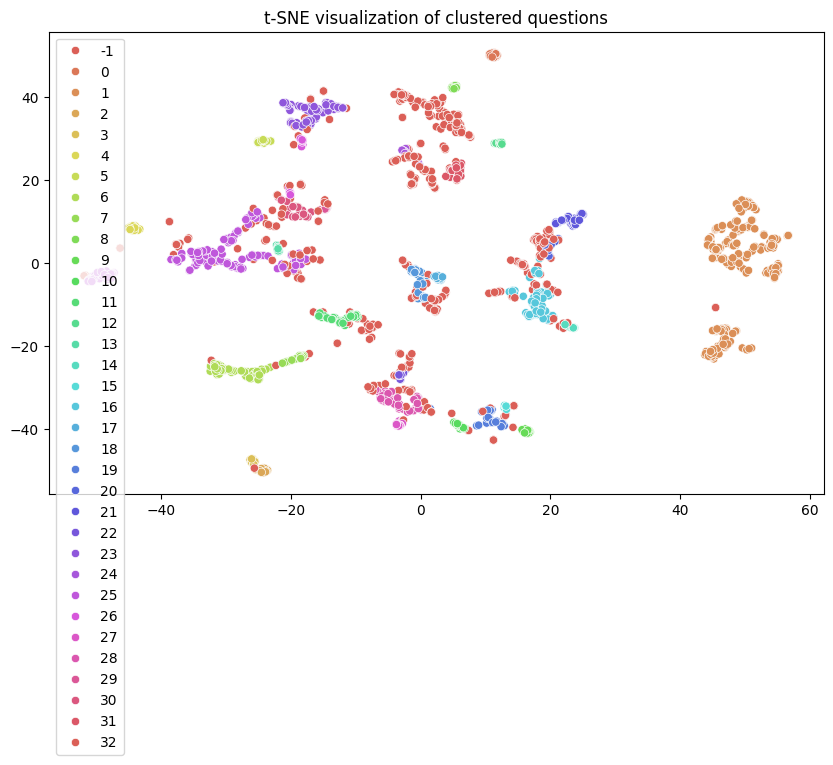

In [15]:
# Evaluation (excluding outliers)
valid_mask = labels != -1
sil_score = silhouette_score(X_umap[valid_mask], labels[valid_mask])
print(f"📈 Silhouette Score (without outliers): {sil_score:.4f}")

# Visualization (t-SNE)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X_umap)

plt.figure(figsize=(10, 6))
palette = sns.color_palette('hls', n_clusters)
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels, palette=palette, legend='full')
plt.title("t-SNE visualization of clustered questions")
plt.show()

Create Cluster Labels with TF-IDF

In [16]:
# TF-IDF Labeling with German stopwords and synonyms
stopwords_de = ["aber", "alle", "als", "also", "am", "an", "ander", "auch", "auf", "aus", "bei", "bin", "bis", "bist", "da", "dadurch", "daher", "darum", "das", "dass", "dein", "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies", "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem", "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte", "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre", "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes", "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen", "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müßt", "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein", "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt", "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom", "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wenn", "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur", "über"]
synonym_map = {
    "vergütung": ["entlohnung", "honorar", "bezahlung"],
    "kündigung": ["beendigung", "auflösung"],
    "vertrag": ["vereinbarung"]
}

def apply_synonyms(texts, mapping):
    updated = []
    for t in texts:
        for target, syns in mapping.items():
            for s in syns:
                t = t.replace(s, target)
        updated.append(t)
    return updated

questions_syn = apply_synonyms(questions, synonym_map)
vectorizer = TfidfVectorizer(stop_words=stopwords_de)
X_tfidf = vectorizer.fit_transform(questions_syn)
feature_names = np.array(vectorizer.get_feature_names_out())

print("\n🔎 Top TF-IDF Keywords per Cluster:")
for cluster_id in sorted(set(labels)):
    if cluster_id == -1: continue  # Skip noise
    cluster_indices = [i for i, label in enumerate(labels) if label == cluster_id]
    cluster_texts = [questions_syn[i] for i in cluster_indices]
    cluster_matrix = vectorizer.transform(cluster_texts).mean(axis=0).A1
    top_keywords = feature_names[cluster_matrix.argsort()[-5:][::-1]]
    print(f"\n📁 Cluster {cluster_id} (n={len(cluster_indices)}):")
    print("Top Keywords:", ", ".join(top_keywords))



🔎 Top TF-IDF Keywords per Cluster:

📁 Cluster 0 (n=22):
Top Keywords: reise, reisende, entschädigung, reiseveranstalter, welche

📁 Cluster 1 (n=254):
Top Keywords: welche, mieter, vermieter, hat, mietvertrag

📁 Cluster 2 (n=20):
Top Keywords: arztes, rechnung, arzt, goä, leistungen

📁 Cluster 3 (n=16):
Top Keywords: befruchtung, abtretungsklausel, künstlichen, künstliche, notwendigkeit

📁 Cluster 4 (n=23):
Top Keywords: berufungsgericht, berufungsurteil, welche, berufungsinstanz, rechtsgrundlage

📁 Cluster 5 (n=19):
Top Keywords: innengesellschaft, unterbeteiligung, schenkung, vollzogen, fischablieferungspflicht

📁 Cluster 6 (n=63):
Top Keywords: versicherungsnehmer, versicherungsnehmers, aufklärungsobliegenheit, versicherer, welche

📁 Cluster 7 (n=21):
Top Keywords: zuteilung, bonuspunkten, rückstellung, überschussverteilung, überschussbeteiligung

📁 Cluster 8 (n=15):
Top Keywords: 89b, hgb, handelsvertreterausgleichs, berechnung, vertragshändler

📁 Cluster 9 (n=18):
Top Keywords: ar

In [17]:
# Save Clusters with embeddings and labels
clustered_cqs = {}
for i, (question, label, emb) in enumerate(zip(questions, labels, embeddings)):
    entry = {
        "cq": question,
        "embedding": emb.tolist(),
    }
    cluster_key = f"Cluster {label}"
    clustered_cqs.setdefault(cluster_key, []).append(entry)

# Save to file
output_path = "competency_questions_output/clustered_CQs_with_embeddings.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(clustered_cqs, f, ensure_ascii=False, indent=4)

In [18]:
# Save clustered CQs
clustered_cqs = {}
for cluster_id in sorted(set(labels)):
    # if cluster_id == -1: continue  #comment to include noise
    clustered_cqs[f"Cluster {cluster_id}"] = [questions[i] for i, label in enumerate(labels) if label == cluster_id]

with open("competency_questions_output/clustered_CQs_hdbscan.json", "w", encoding="utf-8") as f:
    json.dump(clustered_cqs, f, ensure_ascii=False, indent=4)

print("\n✅ Clustered CQs saved to: clustered_CQs_hdbscan.json")



✅ Clustered CQs saved to: clustered_CQs_hdbscan.json
